In [1]:
from __future__ import print_function
import numpy as np
from numpy import newaxis as na
import keras

from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Dropout, Embedding, LSTM
from keras.datasets import imdb
from keras.models import Model
from keras import backend as K

import matplotlib.pyplot as plt
from IPython.display import display, HTML


Using TensorFlow backend.


In [2]:
import os
import sys
import numpy as np
import keras
import shap
from keras.preprocessing.text import Tokenizer
from keras.utils import to_categorical
from keras.preprocessing.sequence import pad_sequences
from keras.layers import Activation, Conv2D, Input, Embedding, Reshape, MaxPool2D, Concatenate, Flatten, Dropout, Dense, Conv1D
from keras.layers import MaxPool1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

from keras.layers import Embedding
# preparing input to our model
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences

# keras layers
from keras.models import Sequential
from keras.layers import Embedding, Bidirectional, LSTM, GRU, Dense
# preparing input to our model
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences

import pandas as pd

# keras layers
from keras.models import Sequential
from keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense

In [3]:
# Let's import and prep the datasets

train=pd.read_csv('not_clean_train.csv', sep=',', encoding='utf-8')
test=pd.read_csv('not_clean_test.csv', sep=',', encoding='utf-8')

train.info()
train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4698 entries, 0 to 4697
Data columns (total 3 columns):
label     4698 non-null object
text      4698 non-null object
target    4698 non-null int64
dtypes: int64(1), object(2)
memory usage: 110.2+ KB


,label,text,target
0,Geopolitical,৫ জানুয়ারি বাংলাদেশে গণতন্ত্র হত্যা দিবস যার ক...,3
1,Gender abusive,আমি লাগাতে চাই তোমরা তো সেই লাগাইছো,4
2,Religious,আই দেখিয়ে দেব এবার ।মুসলিম দের কে এবার জবাই কর...,2
3,Gender abusive,তোরমারে চুদি খানকির পোলা এগুলি কিদেচ,4
4,Geopolitical,আর ভারতের মালাউনরা বাংলাদেশে হিন্দুদের কিছু হল...,3


In [4]:
test.info()
test.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
label     1000 non-null object
text      1000 non-null object
target    1000 non-null int64
dtypes: int64(1), object(2)
memory usage: 23.5+ KB


,label,text,target
0,Geopolitical,ভারতে রেল দূরঘটনায় শেখ হাসিনার শোক আর মায়নমারে...,3
1,Geopolitical,নো পোরোবলেম ভারতের বিতর এর অংশ আছে তাই তারা অব...,3
2,Personal,জুয়েল রানা না মরিয়া প্রমাণ করিল সে জঙ্গি নয় কি...,0
3,Personal,আর আসিফ তোর নুনু এই কারনেই ছোট,0
4,Personal,অন্ধ কে ভিখ্যা দিয়ে ছেড়ে দিতে হয় রাস্তা দেখাতে...,0


In [5]:
test=pd.read_csv('test.csv', sep=',', encoding='utf-8')

In [6]:
import csv 

stop_words='stopwords-bn.txt'
text_data=[]

with open(stop_words,'r',encoding='utf-8') as temp_output_file:
    reader=csv.reader(temp_output_file, delimiter='\n')
    for row in reader:
        text_data.append(row)
stop_word_list=[x[0] for x in text_data]

In [7]:
from nltk.corpus import stopwords  
from nltk.tokenize import word_tokenize  
from nltk.tokenize.treebank import TreebankWordDetokenizer
  
stop_words = set(stop_word_list)  

def textCleaner(example_sent): 
    word_tokens = word_tokenize(example_sent)  
    filtered_sentence = [w for w in word_tokens if not w in stop_words]
    filtered_train = TreebankWordDetokenizer().detokenize(filtered_sentence)

    return filtered_train        

In [8]:
filtered_test = test['text'].apply(textCleaner)

In [9]:
filtered_train = train['text'].apply(textCleaner)

In [10]:
filtered_test

0       পৃথিবীর চাইতে বড় বেঈমান নিমকহারামের জাত পশ্চিম...
1                               ডুবন্ত নৌকায় এক বলদ সাকিব
2                                  ভারত কখনো বন্ধু পারেনা
3                  সমাজবিরোধী কাজকর্ম ৯০% ধর্মের মানুষরাই
4       চলতে সক্ষম কিভাবে অন্যকে খুন পুলিশের অত্যাচারে...
5       যুবলীগ প্রভাবশালী যোগসাজশে ১৪ হিন্দু পরিবার উচ...
6                                   মানুষ কতটা খারাপ এইসব
7                       ফকিন্নির বাচ্চারা জুতা ছিড়ছে কেডা
8                     ভালো আওয়ামী লীগের চোর মামা রব্বানী
9                  রেন্ডিয়ানদের দেখতেও জাত শুয়ারের বাচ্চা
10                      শমী আকাম-কুকাম শাওন করলেই উপন্যাস
11                                     শালিকে ভারত তারিয়ে
12      একটা মানুষকে টাকা পয়সা দেখুন ভিতরে লুকিয়ে অম...
13      আইন সমান ভারতে পালিয়ে যেয়ে দেশে আইনের জামিন মু...
14      ভারত ফ্রি ট্রানজিট ফ্রি বন্দর সুবিধা ফ্রি ব্যা...
15              এশালা খমতা ছেড়ে নির্বাচন দেনা খানকির পোলা
16                             ফকিন্নি জাজ তাহল এমনই হইবো
17      নয়াদিগ

In [11]:
train['label'].value_counts()

Geopolitical      1439
Personal          1282
Religious          801
Political          674
Gender abusive     502
Name: label, dtype: int64

In [12]:
train['target'].value_counts()

3    1439
0    1282
2     801
1     674
4     502
Name: target, dtype: int64

In [13]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(filtered_train, train['target'].values, test_size=0.1, random_state=42)

In [14]:
x_test, y_test = filtered_test, test['target'].values

In [15]:
max_features = 10000

maxlen = 20
batch_size = 32

In [16]:
tokenizer  = Tokenizer(num_words = max_features)
tokenizer.fit_on_texts(x_train)

train_seq =  tokenizer.texts_to_sequences(x_train)
val_seq =  tokenizer.texts_to_sequences(x_val)
test_seq = tokenizer.texts_to_sequences(x_test)

word_index = tokenizer.word_index
print("Unique words : {}".format(len(word_index)))

x_train = pad_sequences(train_seq, maxlen=maxlen, dtype='int32', padding='post') #maxlen = maxlen, padding='post')
x_val = pad_sequences(val_seq, maxlen=maxlen, dtype='int32', padding='post') #maxlen = maxlen, padding='post')
x_test = pad_sequences(test_seq, maxlen=maxlen, dtype='int32', padding='post') #maxlen = maxlen, padding='post')

y_train = np.asarray(y_train)
y_val = np.asarray(y_val)
y_test = np.asarray(y_test)

#y_train = to_categorical(np.asarray(y_train), num_classes=5)
#y_val = to_categorical(np.asarray(y_val), num_classes=5)
#y_test = to_categorical(np.asarray(y_test), num_classes=5)

print('Shape of training data tensor:', x_train.shape)
print('Shape of training label tensor:', y_val.shape)

print('Shape of val data tensor:', x_val.shape)
print('Shape of val label tensor:', y_val.shape)

print('Shape of test data tensor:', x_test.shape)
print('Shape of test label tensor:', y_test.shape)

Unique words : 15248
Shape of training data tensor: (4228, 20)
Shape of training label tensor: (470,)
Shape of val data tensor: (470, 20)
Shape of val label tensor: (470,)
Shape of test data tensor: (1200, 20)
Shape of test label tensor: (1200,)


In [17]:
from gensim.models.keyedvectors import KeyedVectors
from gensim.models import Word2Vec

word_vectors = Word2Vec.load('/home/rkarim/BengHateExplainer/data/Bengali_FastText_DIM20.model')

#word_vectors = Word2Vec.load('C:/Users/admin-karim/Desktop/BengWord2Vec/posts.bin')

In [18]:
NUM_WORDS=20000
EMBEDDING_DIM=20

vocabulary_size=len(tokenizer.word_index)+1
word_index=tokenizer.word_index
embedding_matrix = np.zeros((vocabulary_size, EMBEDDING_DIM))

for word, i in word_index.items():
    if i>=NUM_WORDS:
        continue
    try:
        embedding_vector=word_vectors[word]
        embedding_matrix[i]=embedding_vector
    except KeyError:
        embedding_matrix[i]=np.random.normal(0,np.sqrt(0.25),EMBEDDING_DIM)

del(word_vectors)

In [19]:
embedding_layer=Embedding(vocabulary_size, EMBEDDING_DIM, weights=[embedding_matrix],trainable=False)

In [20]:
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense
from keras.layers import TimeDistributed
from keras.layers import Bidirectional
from keras.layers import Embedding
from keras.initializers import Constant
from keras.layers import *

In [21]:
def BiLSTM_Model():
    model = Sequential()
    model.add(embedding_layer)
    model.add(SpatialDropout1D(0.5))
    model.add(Bidirectional(LSTM(128, return_sequences=True)))
    model.add(Dropout(0.2))
    model.add(Bidirectional(LSTM(64)))
    model.add(Dropout(0.2))
    model.add(Dense(units=128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(units=5, activation='softmax'))
    model.compile(loss = 'sparse_categorical_crossentropy', optimizer='adam', metrics = ['accuracy'])
    
    print(model.summary())
    
    return model     

In [22]:
model = BiLSTM_Model()





Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_1 (Embedding)      (None, None, 20)          304980    
_________________________________________________________________
spatial_dropout1d_1 (Spatial (None, None, 20)          0         
_________________________________________________________________
bidirectional_1 (Bidirection (None, None, 256)         152576    
_________________________________________________________________
dropout_1 (Dropout)          (None, None, 256)         0         
_________________________________________________________________
bidirectional_2 (Bidirection (None, 128)               164352    
_________________________________________________________________
dropout_2 (Dropout)          (None, 128)               0         
______________________

In [23]:
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=100, verbose=1, validation_data=(x_val, y_val))

Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
Train on 4228 samples, validate on 470 samples
Epoch 1/100
4228/4228 [==============================] - 5s 1ms/step - loss: 1.4021 - acc: 0.4347 - val_loss: 1.1919 - val_acc: 0.5170
Epoch 2/100
4228/4228 [==============================] - 3s 765us/step - loss: 1.2684 - acc: 0.5038 - val_loss: 1.0901 - val_acc: 0.5681
Epoch 3/100
4228/4228 [==============================] - 3s 764us/step - loss: 1.2222 - acc: 0.5161 - val_loss: 1.0688 - val_acc: 0.5638
Epoch 4/100
4228/4228 [==============================] - 3s 763us/step - loss: 1.1996 - acc: 0.5277 - val_loss: 1.0495 - val_acc: 0.5915
Epoch 5/100
4228/4228 [==============================] - 3s 764us/step - loss: 1.1770 - acc: 0.5435 - val_loss: 1.0263 - val_acc: 0.5809
Epoch 6/100
4228/4228 [==============================] - 3s 763us/step - loss: 1.1544 - acc: 0.5409 - val_loss: 1.0062 - val_acc: 0.5809
Epoch 7/100
4228/4228 [================

Epoch 58/100
4228/4228 [==============================] - 3s 759us/step - loss: 0.8495 - acc: 0.6743 - val_loss: 0.8560 - val_acc: 0.6851
Epoch 59/100
4228/4228 [==============================] - 3s 759us/step - loss: 0.8268 - acc: 0.6814 - val_loss: 0.8739 - val_acc: 0.6830
Epoch 60/100
4228/4228 [==============================] - 3s 758us/step - loss: 0.8246 - acc: 0.6821 - val_loss: 0.8370 - val_acc: 0.6915
Epoch 61/100
4228/4228 [==============================] - 3s 758us/step - loss: 0.8493 - acc: 0.6790 - val_loss: 0.8546 - val_acc: 0.6681
Epoch 62/100
4228/4228 [==============================] - 3s 759us/step - loss: 0.8346 - acc: 0.6833 - val_loss: 0.9011 - val_acc: 0.6511
Epoch 63/100
4228/4228 [==============================] - 3s 757us/step - loss: 0.8258 - acc: 0.6786 - val_loss: 0.8712 - val_acc: 0.6638
Epoch 64/100
4228/4228 [==============================] - 3s 758us/step - loss: 0.8325 - acc: 0.6861 - val_loss: 0.8909 - val_acc: 0.6681
Epoch 65/100
4228/4228 [==========

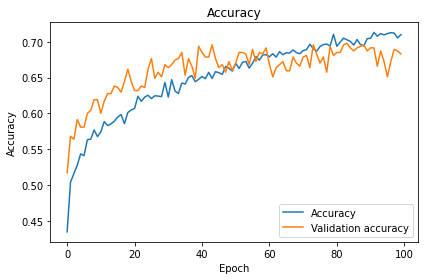

In [24]:
import matplotlib.pyplot as plt

plt.plot(history.history['acc'], label="Accuracy")
plt.plot(history.history['val_acc'], label="Validation accuracy")
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

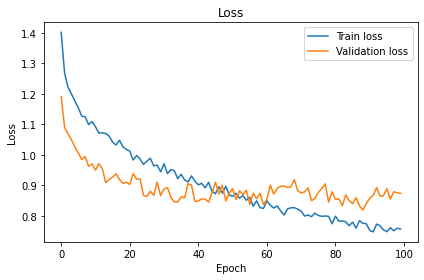

In [25]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label="Train loss")
plt.plot(history.history['val_loss'], label="Validation loss")
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
from sklearn.metrics import classification_report

y_pred = model.predict(x_test)
y_pred = np.argmax(y_pred, axis=1)

In [27]:
y_pred

array([3, 3, 3, ..., 2, 2, 0])

In [28]:
categories = ['Personal', 'Political','Religious','Geopolitical', 'Gender abusive']
print(classification_report(y_test, y_pred, target_names=categories))

                precision    recall  f1-score   support

      Personal       0.68      0.84      0.75       294
     Political       0.88      0.67      0.76       199
     Religious       0.77      0.78      0.78       225
  Geopolitical       0.88      0.84      0.86       353
Gender abusive       0.66      0.62      0.64       129

      accuracy                           0.78      1200
     macro avg       0.77      0.75      0.76      1200
  weighted avg       0.79      0.78      0.78      1200



In [50]:
test['target'].value_counts()

3    353
0    294
2    225
1    199
4    129
Name: target, dtype: int64

In [29]:
def get_layer_output(layer_name, data):
    # https://keras.io/getting-started/faq/#how-can-i-obtain-the-output-of-an-intermediate-layer
    intermediate_layer_model = keras.Model(inputs=model.input,
                                     outputs=model.get_layer(layer_name).output)
    return intermediate_layer_model.predict(data)  

In [30]:
names = [weight.name for layer in model.layers for weight in layer.weights]
weights = model.get_weights()

for name, weight in zip(names, weights):
    print(name)
    #print(weight)

embedding_1/embeddings:0
bidirectional_1/forward_lstm_1/kernel:0
bidirectional_1/forward_lstm_1/recurrent_kernel:0
bidirectional_1/forward_lstm_1/bias:0
bidirectional_1/backward_lstm_1/kernel:0
bidirectional_1/backward_lstm_1/recurrent_kernel:0
bidirectional_1/backward_lstm_1/bias:0
bidirectional_2/forward_lstm_2/kernel:0
bidirectional_2/forward_lstm_2/recurrent_kernel:0
bidirectional_2/forward_lstm_2/bias:0
bidirectional_2/backward_lstm_2/kernel:0
bidirectional_2/backward_lstm_2/recurrent_kernel:0
bidirectional_2/backward_lstm_2/bias:0
dense_1/kernel:0
dense_1/bias:0
dense_2/kernel:0
dense_2/bias:0


In [31]:
# suppress scientific notation
np.set_printoptions(suppress=True)
for name, weight in zip(names, weights):
    if name == 'bidirectional_1/backward_lstm_1/kernel:0':
        kernel_0 = weight
    if name == 'bidirectional_1/backward_lstm_1/recurrent_kernel:0':
        recurrent_kernel_0 = weight
    if name == 'bidirectional_1/backward_lstm_1/bias:0':
        bias_0 = weight
    elif name == 'dense_1/kernel:0':
        output = weight

In [32]:
print("kernel_0", kernel_0.shape)
print("recurrent_kernel_0", recurrent_kernel_0.shape)
print("bias_0", bias_0.shape)
print("output", output.shape)

# self.Wxh_Left (240, 60)
# self.Whh_Left (240, 60)
# self.bxh_Left (240,)
# self.Why_Left (5, 60)

kernel_0 (20, 512)
recurrent_kernel_0 (128, 512)
bias_0 (512,)
output (128, 128)


In [33]:
Wxh = kernel_0.T  # shape 4d*e
Whh = recurrent_kernel_0.T  # shape 4d
bxh = bias_0.T  # shape 4d 
Why = output.T

print("Wxh", Wxh.shape)
print("Whh", Whh.shape)
print("bxh", bxh.shape)
print("Why", Why.shape)

Wxh (512, 20)
Whh (512, 128)
bxh (512,)
Why (128, 128)


In [34]:
def html_heatmap (words, scores, cmap_name="bwr"):
    """
    Return word-level heatmap in HTML format,
    with words being the list of words (as string),
    scores the corresponding list of word-level relevance values,
    and cmap_name the name of the matplotlib diverging colormap.
    """
    
    colormap  = plt.get_cmap(cmap_name)
     
    #assert len(words)==len(scores)
    max_s     = max(scores)
    min_s     = min(scores)
    
    output_text = ""
    
    for idx, w in enumerate(words):
        score       = rescale_score_by_abs(scores[idx], max_s, min_s)
        output_text = output_text + span_word(w, score, colormap) + " "
    
    return output_text + "\n"

def rescale_score_by_abs (score, max_score, min_score):
    """
    Normalize the relevance value (=score), accordingly to the extremal relevance values (max_score and min_score), 
    for visualization with a diverging colormap.
    i.e. rescale positive relevance to the range [0.5, 1.0], and negative relevance to the range [0.0, 0.5],
    using the highest absolute relevance for linear interpolation.
    """
    
    # CASE 1: positive AND negative scores occur --------------------
    if max_score>0 and min_score<0:
    
        if max_score >= abs(min_score):   # deepest color is positive
            if score>=0:
                return 0.5 + 0.5*(score/max_score)
            else:
                return 0.5 - 0.5*(abs(score)/max_score)

        else:                             # deepest color is negative
            if score>=0:
                return 0.5 + 0.5*(score/abs(min_score))
            else:
                return 0.5 - 0.5*(score/min_score)   
    
    # CASE 2: ONLY positive scores occur -----------------------------       
    elif max_score>0 and min_score>=0: 
        if max_score == min_score:
            return 1.0
        else:
            return 0.5 + 0.5*(score/max_score)
    
    # CASE 3: ONLY negative scores occur -----------------------------
    elif max_score<=0 and min_score<0: 
        if max_score == min_score:
            return 0.0
        else:
            return 0.5 - 0.5*(score/min_score)
          

def getRGB (c_tuple):
    return "#%02x%02x%02x"%(int(c_tuple[0]*255), int(c_tuple[1]*255), int(c_tuple[2]*255))

     
def span_word (word, score, colormap):
    return "<span style=\"background-color:"+getRGB(colormap(score))+"\">"+word+"</span>"

In [35]:
def lrp_linear(hin, w, b, hout, Rout, bias_nb_units, eps, bias_factor=0.0, debug=False):
    """
    LRP for a linear layer with input dim D and output dim M.
    Args:
    - hin:            forward pass input, of shape (D,)
    - w:              connection weights, of shape (D, M)
    - b:              biases, of shape (M,)
    - hout:           forward pass output, of shape (M,) (unequal to np.dot(w.T,hin)+b if more than one incoming layer!)
    - Rout:           relevance at layer output, of shape (M,)
    - bias_nb_units:  total number of connected lower-layer units (onto which the bias/stabilizer contribution is redistributed for sanity check)
    - eps:            stabilizer (small positive number)
    - bias_factor:    set to 1.0 to check global relevance conservation, otherwise use 0.0 to ignore bias/stabilizer redistribution (recommended)
    Returns:
    - Rin:            relevance at layer input, of shape (D,)
    """
    sign_out = np.where(hout[na,:]>=0, 1., -1.) # shape (1, M)
    
    numer    = (w * hin[:,na]) + ( bias_factor * (b[na,:]*1. + eps*sign_out*1.) / bias_nb_units ) # shape (D, M)
    # Note: here we multiply the bias_factor with both the bias b and the stabilizer eps since in fact
    # using the term (b[na,:]*1. + eps*sign_out*1.) / bias_nb_units in the numerator is only useful for sanity check
    # (in the initial paper version we were using (bias_factor*b[na,:]*1. + eps*sign_out*1.) / bias_nb_units instead)
    
    denom    = hout[na,:] + (eps*sign_out*1.)   # shape (1, M)
    
    message  = (numer/denom) * Rout[na,:]       # shape (D, M)
    
    Rin      = message.sum(axis=1)              # shape (D,)
    
    if debug:
        print("local diff: ", Rout.sum() - Rin.sum())
    # Note: 
    # - local  layer   relevance conservation if bias_factor==1.0 and bias_nb_units==D (i.e. when only one incoming layer)
    # - global network relevance conservation if bias_factor==1.0 and bias_nb_units set accordingly to the total number of lower-layer connections 
    # -> can be used for sanity check
    
    return Rin

In [36]:
def LRP(target_data, target_class) :
    
    #원본 소스에서 E embedding은 전체에 대한 단어 사전이고, x는 embedding된 인풋이다.  
    # w_indices [109, 11995, 25, 18263, 25, 973, 3138, 6389, 372]

    x = get_layer_output('embedding_1', target_data).squeeze(axis=1)
    e = x.shape[1]

   ################# forword
    T = target_data.shape[0]
    d = int(512/4)  # hidden units
    C = Why.shape[0] # number of classes
    
    idx    = np.hstack((np.arange(0,d), np.arange(2*d,4*d))).astype(int) # indices of gates i,f,o together
    idx_i, idx_g, idx_f, idx_o = np.arange(0,d), np.arange(d,2*d), np.arange(2*d,3*d), np.arange(3*d,4*d) # indices of gates i,g,f,o separately

    h  = np.zeros((T,d))
    c  = np.zeros((T,d))

    gates_xh  = np.zeros((T, 4*d))  
    gates_hh  = np.zeros((T, 4*d)) 
    gates_pre = np.zeros((T, 4*d))  
    gates     = np.zeros((T, 4*d))  

    for t in range(T):
        gates_xh[t]     = np.dot(Wxh, x[t])
        gates_hh[t]     = np.dot(Whh, h[t-1])
        gates_pre[t]    = gates_xh[t] + gates_hh[t] + bxh
        gates[t, idx]    = 1.0/(1.0 + np.exp(- gates_pre[t,idx]))
        gates[t,idx_g]  = np.tanh(gates_pre[t,idx_g]) 
        c[t]            = gates[t,idx_f]*c[t-1] + gates[t,idx_i]*gates[t,idx_g]
        h[t]            = gates[t,idx_o]*np.tanh(c[t])

    s = np.dot(Why, h[t])    

    ################# backwork
    dx     = np.zeros(x.shape)

    dh          = np.zeros((T, d))
    dc          = np.zeros((T, d))
    dgates_pre  = np.zeros((T, 4*d))  # gates pre-activation
    dgates      = np.zeros((T, 4*d))  # gates activation

    ds               = np.zeros((C))
    ds[target_class] = 1.0
    dy               = ds.copy()

    #맨처음을 0으로 시작하지 않게 위한조치
    dh[T-1]     = np.dot(Why.T, dy)

    for t in reversed(range(T)): 
        dgates[t,idx_o]    = dh[t] * np.tanh(c[t])  # do[t]
        dc[t]             += dh[t] * gates[t,idx_o] * (1.-(np.tanh(c[t]))**2) # dc[t]
        dgates[t,idx_f]    = dc[t] * c[t-1]         # df[t]
        dc[t-1]            = dc[t] * gates[t,idx_f] # dc[t-1]
        dgates[t,idx_i]    = dc[t] * gates[t,idx_g] # di[t]
        dgates[t,idx_g]    = dc[t] * gates[t,idx_i] # dg[t]
        dgates_pre[t,idx]  = dgates[t,idx] * gates[t,idx] * (1.0 - gates[t,idx]) # d ifo pre[t]
        dgates_pre[t,idx_g]= dgates[t,idx_g] *  (1.-(gates[t,idx_g])**2) # d g pre[t]
        dh[t-1]            = np.dot(Whh.T, dgates_pre[t])
        dx[t]              = np.dot(Wxh.T, dgates_pre[t])

    ################# LRP
    eps=0.001 
    bias_factor=0.0
    Rx  = np.zeros(x.shape)
    Rh  = np.zeros((T+1, d))
    Rc  = np.zeros((T+1, d))
    Rg  = np.zeros((T,   d)) # gate g only

    Rout_mask            = np.zeros((C))
    Rout_mask[target_class] = 1.0  

    # format reminder: lrp_linear(hin, w, b, hout, Rout, bias_nb_units, eps, bias_factor)
    Rh[T-1]  = lrp_linear(h[T-1], Why.T, np.zeros((C)), s, s*Rout_mask, 2*d, eps, bias_factor, debug=False)  

    for t in reversed(range(T)):
        Rc[t]   += Rh[t]
        Rc[t-1]  = lrp_linear(gates[t,idx_f]*c[t-1], np.identity(d), np.zeros((d)), c[t], Rc[t], 2*d, eps, bias_factor, debug=False)
        Rg[t]    = lrp_linear(gates[t,idx_i]*gates[t,idx_g], np.identity(d), np.zeros((d)), c[t], Rc[t], 2*d, eps, bias_factor, debug=False)
        Rx[t]    = lrp_linear(x[t], Wxh[idx_g].T, bxh[idx_g], gates_pre[t,idx_g], Rg[t], d+e, eps, bias_factor, debug=False)
        Rh[t-1]  = lrp_linear(h[t-1], Whh[idx_g].T, bxh[idx_g], gates_pre[t,idx_g], Rg[t], d+e, eps, bias_factor, debug=False)    

    return s, dx, Rx, Rh[-1].sum()

In [37]:
#word_index = imdb.get_word_index()
index_word = {v:k for k,v in word_index.items()}

#values = ','.join(str(v) for v in value_list)

def index_to_word(word):
    full_sentence = ' '.join(index_word.get(w) for w in word)
    return full_sentence.split()

In [38]:
def int_to_str(target_class):
    if target_class == 0:
        return "Personal"
    elif target_class == 1:
        return "Political"
    elif target_class == 2:
        return "Religious"
    elif target_class == 3:
        return "Geopolitical"
    else:
        return "Fake"

In [39]:
predictions = model.predict(x_test)

In [40]:
per_list = []
poli_list = []
reli_list = []
geo_list = []
gend_list = []

for i in range(len(y_test)):
    if np.argmax(predictions[i]) == 0:
        per_list.append(i)
    elif np.argmax(predictions[i]) == 1:
        poli_list.append(i)
    elif np.argmax(predictions[i]) == 2:
        reli_list.append(i)
    elif np.argmax(predictions[i]) == 3:
        geo_list.append(i)
    else:
        gend_list.append(i)

In [41]:
index_word = {v: k for k, v in word_index.items()} # map back
seqs = x_test
words = []

def seqToWords():
    for seq in seqs:
        if len(seq):
            words.append(index_word.get(seq[0]))
        else:
            words.append(' ')    
            
    return words

In [42]:
words = seqToWords()

In [43]:
# Creating a reverse dictionary
reverse_word_map = dict(map(reversed, word_index.items()))

# Function takes a tokenized sentence and returns the words
def sequence_to_text(list_of_indices):
    # Looking up words in dictionary
    words = [reverse_word_map.get(letter) for letter in list_of_indices]
    
    return words

In [44]:
def explainer(class_list):   
    for index, i in enumerate(class_list):
    
        target_data = x_test[i]
        print(target_data)
        print(target_data.shape)
        target_class = np.argmax(y_test[i])

        scores, Gx, Rx, R_rest = LRP(target_data, target_class)
    
        R_words          = np.sum(Rx, axis=1)                       # compute word-level LRP relevances
        R_words_SA       = (np.linalg.norm(Gx,ord=2, axis=0))**2   # compute word-level Sensitivity Analysis relevances
        R_words_GI       = np.dot(target_data, Gx) 
    
        try:
            words = index_to_word(target_data)
            #continue
        #words = seqToWords()
        except:
            continue

        if len(words) > 0 :
            print("Predicted label:", int_to_str(np.argmax(predictions[i])), "Actual label:", int_to_str(target_class))

            print("LRP heatmap:")
            display(HTML(html_heatmap(words, R_words)))

            print("SA heatmap:")
            display(HTML(html_heatmap(words, R_words_SA)))

            print("GI heatmap:")
            display(HTML(html_heatmap(words, R_words_GI)))

            print("-----------------------------------------------------------")

        if index == 50: 
            break

In [45]:
print("The degree to which each word affects the prediction of being religious hates...")
explainer(reli_list)

The degree to which each word affects the prediction of being religious hates...
[ 530 2643   18 1355    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[8040 8041  184 1715   25    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[1281 1623 6685   10 6686 6687  358 6688 6689  380 1141 1922 3715    0
    0    0    0    0    0    0]
(20,)
[ 147   28 1278 1447   91  207  243   51 3134  114  138 4940  261  900
 4746  467 1067  206  854 1067]
(20,)
Predicted label: Religious Actual label: Personal
LRP heatmap:


SA heatmap:


GI heatmap:


-----------------------------------------------------------
[ 151   48  496   25   28  518 2783  344  889 2026    4  670    9 1415
   17  859  859  613   49  151]
(20,)
Predicted label: Religious Actual label: Personal
LRP heatmap:


SA heatmap:


...

GI heatmap:


-----------------------------------------------------------
[1240 1380  565 5093  669   41   19   19   41    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 105  329 4464 9010 2947 9011 2577  109 9013 1426 1833 1938  101 2086
    0    0    0    0    0    0]
(20,)
[ 303 7201   76  521  645 7202 7203 2692 3509   63  201  159 7204  132
 7205  314  115 7206    0    0]
(20,)
[ 205 1775  242 1976  218 5047  205 1675 4669  270 2068 3149   91 1319
 2364 1976 1319    0    0    0]
(20,)
[435 449 449  28  28   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0]
(20,)
[5976 5977 5978 5979 3447 1890 2462  115    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 168  317   77   99 9150 9151 9152 1965 9153 2920  867    0    0    0
    0    0    0    0    0    0]
(20,)
[ 965   18 7788 2781 4089   18   41  450 7789   11 7790    0    0    0
    0    0    0    0    0    0]
(20,)
[   1   11 1550  609  251    0    0    0    0    0    0    0    0    0
    0    0    0  

SA heatmap:


GI heatmap:


-----------------------------------------------------------
[1029    5   30   71   30    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[1045   11 3862    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[3305   96   25  625 1119   77    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[1037   67  476  828  131   92  100  362    4 3345  100    0    0    0
    0    0    0    0    0    0]
(20,)
[ 116  348 4274 8345  669 8346   71 2871  143  957 8347  143  116  669
    0    0    0    0    0    0]
(20,)
[  18   10 2539    4  885   93   38  178  428  171  209  132  305  219
 1943  191    0    0    0    0]
(20,)
[ 974  155  624 1945 8944 1427 4457 4458 2568  822    0    0    0    0
    0    0    0    0    0    0]
(20,)
[1389  102  868  778  896    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 348 2060 2060 3052 2060    6  684    6 1778  120 2091 4643    4 14

In [46]:
print("The degree to which each word affects the prediction of being geopolitical hates...")
explainer(geo_list)

The degree to which each word affects the prediction of being geopolitical hates...
[1470 4820   69  383  185 4542   44 4822 1469 3074   31 2214 2755 2305
    7    4 4821 3032 4821 4822]
(20,)
Predicted label: Geopolitical Actual label: Personal
LRP heatmap:


SA heatmap:


GI heatmap:


-----------------------------------------------------------
[9297 4540   22  827  869    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  1 271 198 510   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0]
(20,)
[4900    1 4687    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 536  460   16 1487 1815   34 1056 2344  584  182 2345   46    6  146
 1488 1056 5495  584  227    0]
(20,)
[   1 1889 1444 1889 4861 1753 1889 2858  198  239  328 8354  433 3094
   73   45    0    0    0    0]
(20,)
[2280  945  427  108    2   29 4393   29  211 2280  211  223 4532 2280
    0    0    0    0    0    0]
(20,)
[  84   12 9058 4479 9059   22 9060 9061   46    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[1042 6016 6017 6018 2466  822   14   70 3459 3460 1101 3460 1102 2466
  822  669    0    0    0    0]
(20,)
[ 360 1075  292 1601 4414 1275  560 2814 1390   57    0    0    0    0
    0    0    0  

SA heatmap:


...

GI heatmap:


-----------------------------------------------------------
[   1  539  107 1375    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 538   42   36 6335  556 3645   36  239   36   15 3890  172   55   20
  172   55 2657 1168   16 4396]
(20,)
Predicted label: Geopolitical Actual label: Personal
LRP heatmap:


SA heatmap:


GI heatmap:


-----------------------------------------------------------
[   1    7 2059  461  362 1691   65  256   68 3886  508 7644  125 7645
    0    0    0    0    0    0]
(20,)
[   1 1360  198  838    7  505    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 312 1437 3077  680   13  262  464   43  479  169    0    0    0    0
    0    0    0    0    0    0]
(20,)
[   2 5271  231  231   65 2387  181 3999  125  743  405  864 2343   54
   46 9751  737 1858    0    0]
(20,)
[1444    1    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 167 4413 8791  852  158 2197 8793   59 8794   10 8795    0    0    0
    0    0    0    0    0    0]
(20,)
[   2  346  139  843   13  565 1983   17  232  538  895    0    0    0
    0    0    0    0    0    0]
(20,)
[  27 1435 5006  895  851 1435 1090 1843  631   11    0    0    0    0
    0    0    0    0    0    0]
(20,)
[   1  545  172 3590 6369 1113  430 3345  252    2    0    0    0   

In [47]:
print("The degree to which each word affects the prediction of being personal hates...")
explainer(per_list)

The degree to which each word affects the prediction of being personal hates...
[1524  120    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[1068  135 2122  262  323  279   64  103    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 13 864  56 466   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0]
(20,)
[809 201  98   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0]
(20,)
[   5  206   42 9028  405  940 4456 9029 4469  382  376    0    0    0
    0    0    0    0    0    0]
(20,)
[1664 1956 7187    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[3093  692 1331  937    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[4317 1111  858   39   13  467    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[5144 2446 1781  132   30 2455 1239  315    0    0    0    0    0    0
    0    0    0  

SA heatmap:


GI heatmap:


-----------------------------------------------------------
[  37   94  136   19 2085 3048 3048 4772 3048 4772  136    5  113  115
 4773    0    0    0    0    0]
(20,)
[4400 4967 8221 2380  202 5977 3124    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  20  949 2449 1891 4666    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[1727 1062 1952    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 954    5 9704  491   10 9705 9706 9707 9708    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 127 1095  565  204    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 168  635  852 9229  124    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[150 159 183   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0]
(20,)
[ 136  418 1708  542  439  340  214   86  374    0    0    0    0    0
    0    0    0  

SA heatmap:


...

GI heatmap:


-----------------------------------------------------------
[2112  717  230   35   82  717 2283    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[1207 3042 3847 4759 4760  694 4761 2462    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 873  335  133   46 2085    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 708 1761    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  37   94  189   37   94  189   91  737 3988    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 358 5197   10   39 5197    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[1269 1376 1001 1176 2168    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[2119   62  124    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[2852  387  474    0    0    0    0    0    0    0    0    0    0   

SA heatmap:


GI heatmap:


-----------------------------------------------------------
[ 888  389  918  648  595 1419 5192 8576  721    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[350 552 709 532   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0]
(20,)
[   8 5265 3191 1073  209  830 3191    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[1451  476  762  797    9   12 2137    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 368 1029  181    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  74 2924    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 313 3291   78  245 1603    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[2647 3100   56 2647    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 790    6   20 5159 3741  174 1495    0    0    0    0    0    0    0
    0    0    0  

In [48]:
print("The degree to which each word affects the prediction of being gender abusive hates...")
explainer(gend_list)

The degree to which each word affects the prediction of being gender abusive hates...
[7557 2087 7558 7559  745 3822    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[8962   33  310 1210   39   22    6 1316 8963 8964    0    0    0    0
    0    0    0    0    0    0]
(20,)
[1285    5   92   51 1036 8120   28    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 499 1006 1714 9222 1714  600   92 1699    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 754 9687  330 1144 9688 3004 9689    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 903  189  189  279  132 1822    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[3471  103  453  103 1215  103 1441  103  103    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[1334  499 1335  178 6395    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  35  492 1587 1752 1937  180  156  171 1

[ 37 161 153 918 153   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0]
(20,)
[  35 1249  324   87   91  298    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 92 796 605 153   9   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0]
(20,)
[3798 3798   59  363  721  324   87  721    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 100 1626 6781    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 40  92   8  38 103  20 242  40   0   0   0   0   0   0   0   0   0   0
   0   0]
(20,)
[6903  235  270   80 6739  408  322 1957   52  408 2311  466 1690  238
  137    9    0    0    0    0]
(20,)
[ 84  24 331 142  56 166 166 166   0   0   0   0   0   0   0   0   0   0
   0   0]
(20,)
[  14 8384   40 8385  180    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 131   35   82 1579   66  305    0    0    0    0    0    0    0    0
    0    0    0    0    0   

SA heatmap:


GI heatmap:


-----------------------------------------------------------
[  35 1231  132 1802  184   35   25  715  806   64  345    0    0    0
    0    0    0    0    0    0]
(20,)
[4588  947   55    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 754 1683 2728  908  166    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[   8 7368  336 2560  594    8  132  284 2940   14   35  661 1558 3927
 1671   32   35  125 2064 7370]
(20,)
Predicted label: Fake Actual label: Personal
LRP heatmap:


SA heatmap:


GI heatmap:


-----------------------------------------------------------
[ 310 4233 2774   33 8789  633    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[4009 9454 1299 9455   12 4587    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 351  603 1272  160 2929    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 377   25    8 6263 6264   35   25  364    8 1087  104 2420    0    0
    0    0    0    0    0    0]
(20,)
[ 432 1671  254 2513 1390    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[5002 4175  228  540 2331  115    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  16  589   26  168 1739 1151 1549 7423  168  204    0    0    0    0
    0    0    0    0    0    0]
(20,)
[2082  327  602 5137  986 2215    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[5031  379  988  217    8  840 2012    0    0    0    0    0    0   

In [49]:
print("The degree to which each word affects the prediction of being politicl hates...")
explainer(poli_list)

The degree to which each word affects the prediction of being politicl hates...
[  19  246  118  122 2464 2751    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[2238  330  173   35   82    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 903  252  586  573 2969    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  45  106 2007   34 1197    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[2054   33  644  252   76 7262 3458 1665  483  494  144 1381  153 7263
    0    0    0    0    0    0]
(20,)
[  34 1869  209   62  253 1115 1302   17 2408 1523  362   74   34  364
    0    0    0    0    0    0]
(20,)
[ 243 6826  163   26   22   57   22  702  102    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[1040 1971  479  523  479    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  12   90 1581  266  287   17    0    0    0   

SA heatmap:


GI heatmap:


-----------------------------------------------------------
[  34  223 2606  173  130  483 6679   38   75    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 222  194  565 9477  265 4436 9478 9479  222  194  700 9480 9481    0
    0    0    0    0    0    0]
(20,)
[308 753  36   5  77 863 609  69   0   0   0   0   0   0   0   0   0   0
   0   0]
(20,)
[3532  401 4898 1131    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[1473  261 3238   32  409 3392  675    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 308 3195 2232  719    6   15  956 2232 3819  196    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 981 1324   32 7964  125 2823 2176 2823 7966   53  118 1337 2387 1017
 7968 2823 2790 1025  323 7969]
(20,)
Predicted label: Political Actual label: Personal
LRP heatmap:


SA heatmap:


...

GI heatmap:


-----------------------------------------------------------
[8232 2005   97  741    5  189  390 8233    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[   8 8084 8085  413 8086    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[  14  122  266  145 1010    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[1011  190 4660 1886  190  116   67 1577   71 2073 1182   32 5311   53
   58 1617  173  639    0    0]
(20,)
[ 170  144  301 1262 1262 1556 1209  301  619 4254 1298   49    0    0
    0    0    0    0    0    0]
(20,)
[2075 3973  274 3188   50   32  306    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 148  163  140   38  834  140  279 1315  241    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[1189 9278 1730 1014 8089  297 1014   88    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 169 4675  876  194  848  629  470 2272    0    0    0    0    0   

SA heatmap:


GI heatmap:


-----------------------------------------------------------
[219   4 514 380 349  57  32 409 825   0   0   0   0   0   0   0   0   0
   0   0]
(20,)
[ 125   32   49  702    4   14 2027    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[1599 2070 2070  243 2070  775   74   38  429  512  649 1282   83    0
    0    0    0    0    0    0]
(20,)
[ 635  202 1639  709 1020   83  776    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 220   58 1054  702 6987   58 6988   58    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 148 2480   62    9   47    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 220   58 5007  403 1711    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[ 702 4267 1056 5008 1247 1020  898    0    0    0    0    0    0    0
    0    0    0    0    0    0]
(20,)
[1702 1301   32   71    9   47  811   69 4960    0    0    0    0    0
    0    0    0  